# Taming Overfitting: Regularisation in a Neural Network
## https://github.com/SaiAkhil24/mlp-regularisation-tutorial
### Name: SAIAKHIL CHAVVAKULA | Roll Number: 24176739

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Accessibility: Okabe-Ito colour-blind-safe palette + distinct markers/linestyles
CB = {'blue':'#0072B2','orange':'#E69F00','green':'#009E73',
      'red':'#D55E00','grey':'#999999'}
plt.rcParams.update({'figure.dpi':110,'font.size':13,'axes.grid':True,
                     'grid.alpha':0.3})
rng_global = np.random.default_rng(0)

## 1. A dataset where overfitting is easy to see

We generate the classic **two-moons** problem (Pedregosa et al., 2011) with NumPy (no scikit-learn). Using a
**small, noisy training set** (120 points) makes the gap between memorising and
generalising obvious. A separate validation set is used to *watch* generalisation
during training, and a large test set gives an honest final score.

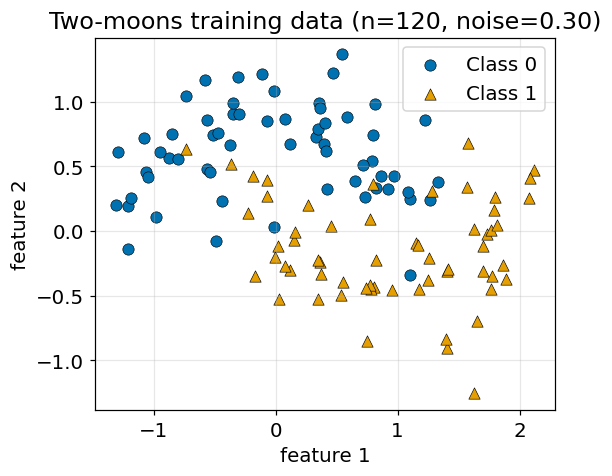

In [10]:
def make_moons(n_samples=300, noise=0.30, seed=0):
    rng = np.random.default_rng(seed)
    n_a = n_samples // 2; n_b = n_samples - n_a
    t_a = np.linspace(0, np.pi, n_a); t_b = np.linspace(0, np.pi, n_b)
    outer = np.c_[np.cos(t_a), np.sin(t_a)]
    inner = np.c_[1 - np.cos(t_b), 1 - np.sin(t_b) - 0.5]
    X = np.vstack([outer, inner]).astype(float)
    y = np.hstack([np.zeros(n_a), np.ones(n_b)]).astype(float)
    X += rng.normal(0, noise, X.shape)
    idx = rng.permutation(n_samples)
    return X[idx], y[idx]

def standardise(X, mu=None, sd=None):
    if mu is None:
        mu, sd = X.mean(0), X.std(0) + 1e-8
    return (X - mu) / sd, mu, sd

Xtr, ytr = make_moons(120, 0.30, seed=1)
Xval, yval = make_moons(400, 0.30, seed=2)
Xte, yte = make_moons(2000, 0.30, seed=3)
Xtr_s, mu, sd = standardise(Xtr)
Xval_s, _, _ = standardise(Xval, mu, sd)
Xte_s, _, _ = standardise(Xte, mu, sd)

fig, ax = plt.subplots(figsize=(5.4,4.4))
for c, col, mk, lab in [(0,CB['blue'],'o','Class 0'),(1,CB['orange'],'^','Class 1')]:
    m = ytr==c
    ax.scatter(Xtr[m,0],Xtr[m,1],c=col,marker=mk,s=55,edgecolor='k',
               linewidth=0.4,label=lab)
ax.set(title='Two-moons training data (n=120, noise=0.30)',
       xlabel='feature 1',ylabel='feature 2'); ax.legend(); plt.show()

## 2. The MLP, written from scratch

The network is `2 -> 64 -> 64 -> 1` with ReLU hidden units and a sigmoid output,
trained with binary cross-entropy and the **Adam** optimiser (Kingma and Ba, 2015).
Two regularisers are built directly into the maths:

- **L2 weight decay** (Krogh and Hertz, 1991) adds `0.5 * lambda * ||W||^2` to the
  loss, which becomes `+ lambda * W` in every weight gradient - it gently pulls
  weights toward zero.
- **Inverted dropout** (Srivastava et al., 2014) randomly zeroes a fraction of hidden
  units each step and rescales the rest, so the network cannot rely on any single unit.

In [11]:
class MLP:
    def __init__(self, sizes, l2=0.0, dropout=0.0, seed=0):
        self.l2, self.dropout = l2, dropout
        rng = np.random.default_rng(seed)
        self.W = [rng.normal(0, np.sqrt(2/i), (i,o))
                  for i,o in zip(sizes[:-1], sizes[1:])]   # He init
        self.b = [np.zeros(o) for o in sizes[1:]]
        self.mW=[np.zeros_like(w) for w in self.W]; self.vW=[np.zeros_like(w) for w in self.W]
        self.mb=[np.zeros_like(b) for b in self.b]; self.vb=[np.zeros_like(b) for b in self.b]
        self.t=0
    relu = staticmethod(lambda z: np.maximum(0,z))
    sig  = staticmethod(lambda z: 1/(1+np.exp(-np.clip(z,-30,30))))
    def forward(self, X, train=False, rng=None):
        a, caches, L = X, [], len(self.W)
        for i in range(L):
            z = a @ self.W[i] + self.b[i]
            if i < L-1:
                h = self.relu(z); mask=None
                if train and self.dropout>0:
                    mask = (rng.random(h.shape) > self.dropout)/(1-self.dropout)
                    h = h*mask
                caches.append((a,z,mask)); a = h
            else:
                out = self.sig(z); caches.append((a,z,None))
        return out, caches
    def loss(self, X, y):
        p,_ = self.forward(X); p = np.clip(p.ravel(),1e-9,1-1e-9)
        bce = -np.mean(y*np.log(p)+(1-y)*np.log(1-p))
        return bce + 0.5*self.l2*sum((w**2).sum() for w in self.W)/len(y)
    def predict_proba(self, X):
        return self.forward(X)[0].ravel()
    def fit(self, Xtr, ytr, Xval, yval, epochs=4000, lr=1e-2,
            patience=None, seed=0, record=True):
        rng = np.random.default_rng(seed); y = ytr.reshape(-1,1); n=len(Xtr)
        hist={'train':[],'val':[],'epoch':[]}
        best,bstate,bep,wait = np.inf,None,0,0; b1,b2,eps=0.9,0.999,1e-8
        for ep in range(epochs):
            out,caches = self.forward(Xtr, train=True, rng=rng)
            dz = (out - y)/n
            gW=[None]*len(self.W); gb=[None]*len(self.b)
            for i in reversed(range(len(self.W))):
                a_prev,z,mask = caches[i]
                gW[i] = a_prev.T@dz + self.l2*self.W[i]/n; gb[i]=dz.sum(0)
                if i>0:
                    _,z_prev,mask_prev = caches[i-1]
                    da = dz @ self.W[i].T
                    drelu = (z_prev>0).astype(float)
                    if mask_prev is not None: drelu = drelu*mask_prev
                    dz = da*drelu
            self.t += 1
            for i in range(len(self.W)):
                self.mW[i]=b1*self.mW[i]+(1-b1)*gW[i]; self.vW[i]=b2*self.vW[i]+(1-b2)*gW[i]**2
                self.W[i]-=lr*(self.mW[i]/(1-b1**self.t))/(np.sqrt(self.vW[i]/(1-b2**self.t))+eps)
                self.mb[i]=b1*self.mb[i]+(1-b1)*gb[i]; self.vb[i]=b2*self.vb[i]+(1-b2)*gb[i]**2
                self.b[i]-=lr*(self.mb[i]/(1-b1**self.t))/(np.sqrt(self.vb[i]/(1-b2**self.t))+eps)
            if record and (ep%20==0 or ep==epochs-1):
                hist['train'].append(self.loss(Xtr,ytr)); hist['val'].append(self.loss(Xval,yval))
                hist['epoch'].append(ep)
            if patience is not None:
                lv = self.loss(Xval,yval)
                if lv < best-1e-5:
                    best,bep,wait = lv,ep,0
                    bstate=([w.copy() for w in self.W],[b.copy() for b in self.b])
                else:
                    wait+=1
                    if wait>=patience: break
        if patience is not None and bstate is not None: self.W,self.b = bstate
        hist['best_epoch']=bep; return hist

def accuracy(model,X,y):
    return float(((model.predict_proba(X)>0.5).astype(float)==y).mean())

## 3. Overfitting in one picture

We train two identical networks: one with **no regularisation** and one with
**L2 weight decay** (`lambda=1`). The decision boundary of the unregularised model
twists to capture every noisy point (even forming little islands), while the
regularised model keeps the smooth shape the data actually has.

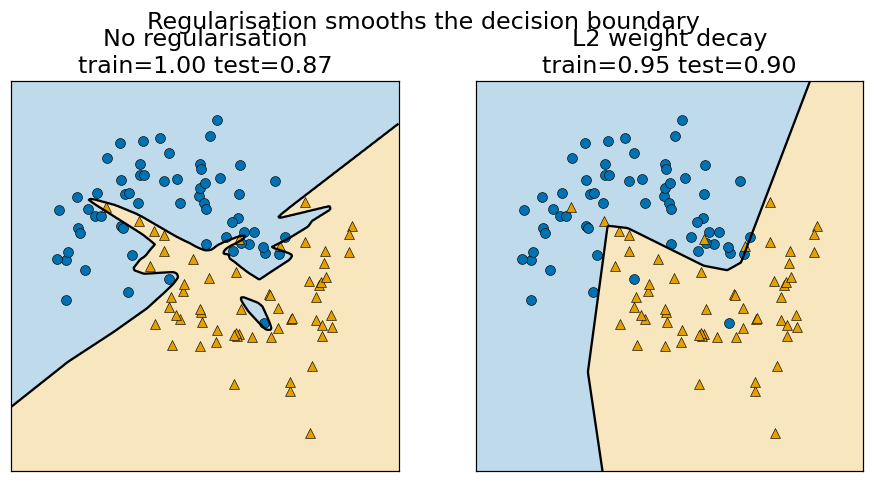

In [12]:
arch = [2,64,64,1]
plain = MLP(arch, l2=0.0); h_plain = plain.fit(Xtr_s,ytr,Xval_s,yval)
reg   = MLP(arch, l2=1.0); h_reg   = reg.fit(Xtr_s,ytr,Xval_s,yval)

def boundary(ax, model, title):
    pad=0.6
    xx,yy = np.meshgrid(np.linspace(Xtr_s[:,0].min()-pad,Xtr_s[:,0].max()+pad,300),
                        np.linspace(Xtr_s[:,1].min()-pad,Xtr_s[:,1].max()+pad,300))
    zz = model.predict_proba(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx,yy,zz,levels=[0,0.5,1],colors=[CB['blue'],CB['orange']],alpha=0.25)
    ax.contour(xx,yy,zz,levels=[0.5],colors='k',linewidths=1.5)
    for c,col,mk in [(0,CB['blue'],'o'),(1,CB['orange'],'^')]:
        m=ytr==c; ax.scatter(Xtr_s[m,0],Xtr_s[m,1],c=col,marker=mk,s=42,
                             edgecolor='k',linewidth=0.4)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

fig,ax = plt.subplots(1,2,figsize=(10,4.6))
boundary(ax[0],plain,f"No regularisation\ntrain={accuracy(plain,Xtr_s,ytr):.2f} test={accuracy(plain,Xte_s,yte):.2f}")
boundary(ax[1],reg,  f"L2 weight decay\ntrain={accuracy(reg,Xtr_s,ytr):.2f} test={accuracy(reg,Xte_s,yte):.2f}")
fig.suptitle('Regularisation smooths the decision boundary',y=1.02); plt.show()

### The same story as a learning curve

Overfitting has a signature: training loss keeps falling while **validation loss
turns around and rises**. With L2, the two curves stay close together.

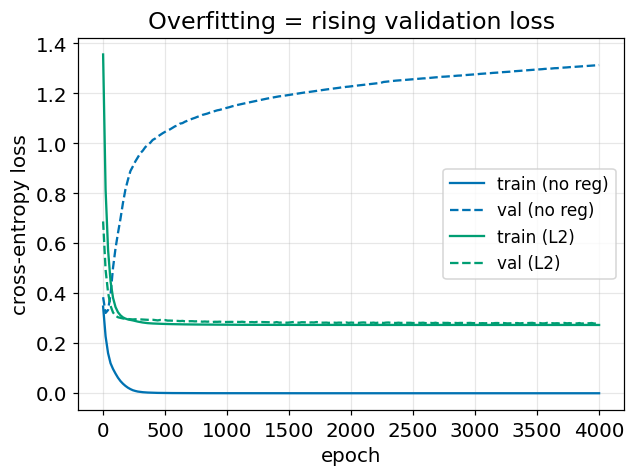

In [13]:
fig,ax = plt.subplots(figsize=(6.4,4.4))
ax.plot(h_plain['epoch'],h_plain['train'],color=CB['blue'],ls='-',label='train (no reg)')
ax.plot(h_plain['epoch'],h_plain['val'],  color=CB['blue'],ls='--',label='val (no reg)')
ax.plot(h_reg['epoch'],  h_reg['train'],  color=CB['green'],ls='-',label='train (L2)')
ax.plot(h_reg['epoch'],  h_reg['val'],    color=CB['green'],ls='--',label='val (L2)')
ax.set(xlabel='epoch',ylabel='cross-entropy loss',
       title='Overfitting = rising validation loss'); ax.legend(fontsize=11); plt.show()

## 4. How much regularisation? The generalisation curve

Sweeping the L2 strength `lambda` reveals the **bias-variance trade-off**. Too small
and the model overfits (high train, lower test); too large and it underfits (both
collapse toward chance). The sweet spot here is around `lambda=1`.

In [ ]:
lambdas = [0,0.03,0.1,0.3,1,3,10,30,100]
tr,te = [],[]
for lam in lambdas:
    m = MLP(arch, l2=lam); m.fit(Xtr_s,ytr,Xval_s,yval,epochs=3000,record=False)
    tr.append(accuracy(m,Xtr_s,ytr)); te.append(accuracy(m,Xte_s,yte))
x = np.arange(len(lambdas)); best = int(np.argmax(te))
fig,ax = plt.subplots(figsize=(6.4,4.4))
ax.plot(x,tr,color=CB['blue'],marker='o',label='train accuracy')
ax.plot(x,te,color=CB['red'],marker='s',ls='--',label='test accuracy')
ax.axvline(best,color=CB['grey'],ls=':',lw=2)
ax.annotate('best\ngeneralisation',(best,te[best]),textcoords='offset points',xytext=(8,-38),fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(lambdas,rotation=45)
ax.set(xlabel='L2 strength  lambda',ylabel='accuracy',
       title='Too little -> overfit;  too much -> underfit'); ax.legend(fontsize=11); plt.show()

## 5. Early stopping: free regularisation

Instead of changing the loss, we simply **stop training at the lowest validation
loss** (Prechelt, 1998). It costs nothing extra and often matches explicit penalties.

In [ ]:
es = MLP(arch, l2=0.0); h_es = es.fit(Xtr_s,ytr,Xval_s,yval,patience=15)
fig,ax = plt.subplots(figsize=(6.4,4.4))
ax.plot(h_plain['epoch'],h_plain['train'],color=CB['blue'],ls='-',label='train loss')
ax.plot(h_plain['epoch'],h_plain['val'],color=CB['orange'],ls='--',label='val loss')
ax.axvline(h_es['best_epoch'],color=CB['red'],lw=2,label=f"early stop @ epoch {h_es['best_epoch']}")
ax.set(xlabel='epoch',ylabel='cross-entropy loss',
       title='Early stopping halts at minimum validation loss'); ax.legend(fontsize=11); plt.show()

print('No reg     : train=%.3f test=%.3f' % (accuracy(plain,Xtr_s,ytr),accuracy(plain,Xte_s,yte)))
print('L2 (lam=1) : train=%.3f test=%.3f' % (accuracy(reg,Xtr_s,ytr),accuracy(reg,Xte_s,yte)))
print('Early stop : train=%.3f test=%.3f (epoch %d)' % (accuracy(es,Xtr_s,ytr),accuracy(es,Xte_s,yte),h_es['best_epoch']))

## 6. Dropout: training an ensemble for free

L2 is not the only option. **Dropout** (Srivastava et al., 2014) randomly switches off a fraction of hidden
units on every training step (rescaling the survivors so the expected signal is
unchanged). The network can no longer rely on any single unit, so it learns
redundant, robust features - effectively training a huge *ensemble* of sub-networks
that share weights. Below we train the same architecture with `dropout=0.6` and
compare it with the unregularised model.

A useful honesty check: on this tiny 2-feature problem dropout is a *blunt* tool -
it lowers training accuracy and lifts test accuracy a little, but does not beat L2
here. Dropout's real power shows in **large, deep networks** with many units, where
L2 alone is not enough; this small demo just makes the mechanism visible.

In [ ]:
drop = MLP(arch, l2=0.0, dropout=0.6); drop.fit(Xtr_s, ytr, Xval_s, yval)
fig, ax = plt.subplots(1, 2, figsize=(10,4.6))
boundary(ax[0], plain, f"No regularisation\ntrain={accuracy(plain,Xtr_s,ytr):.2f} test={accuracy(plain,Xte_s,yte):.2f}")
boundary(ax[1], drop,  f"Dropout p=0.6\ntrain={accuracy(drop,Xtr_s,ytr):.2f} test={accuracy(drop,Xte_s,yte):.2f}")
fig.suptitle('Dropout reduces overfitting', y=1.02); plt.show()

print('Dropout 0.6 : train=%.3f test=%.3f' %
      (accuracy(drop,Xtr_s,ytr), accuracy(drop,Xte_s,yte)))

## 7. Takeaways

- **Overfitting** is a model fitting noise; its tell-tale sign is a validation loss
  that rises while training loss falls.
- **L2 weight decay** shrinks weights and smooths the decision boundary.
- **Dropout** (set `dropout=0.3` in the `MLP`) prevents co-adaptation of units.
- **Early stopping** is the cheapest regulariser - just stop at the best val loss.
- Always tune regularisation strength on a **validation set**, never the test set.

### References (Harvard) & resources used

Goodfellow, I., Bengio, Y. and Courville, A. (2016) *Deep Learning*. Cambridge, MA: MIT Press. Available at: https://www.deeplearningbook.org/

Kingma, D.P. and Ba, J. (2015) 'Adam: a method for stochastic optimization', *Proceedings of the 3rd International Conference on Learning Representations (ICLR)*. Available at: https://arxiv.org/abs/1412.6980

Krogh, A. and Hertz, J.A. (1991) 'A simple weight decay can improve generalization', *Advances in Neural Information Processing Systems 4*, pp. 950-957. Available at: https://proceedings.neurips.cc/paper/1991/hash/8eefcfdf5990e441f0fb6f3fad709e21-Abstract.html

Pedregosa, F. et al. (2011) 'Scikit-learn: machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825-2830. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html

Prechelt, L. (1998) 'Early stopping - but when?', in Orr, G.B. and Müller, K.-R. (eds.) *Neural Networks: Tricks of the Trade*. Berlin: Springer, pp. 55-69. Available at: https://doi.org/10.1007/3-540-49430-8_3

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I. and Salakhutdinov, R. (2014) 'Dropout: a simple way to prevent neural networks from overfitting', *Journal of Machine Learning Research*, 15, pp. 1929-1958. Available at: https://jmlr.org/papers/v15/srivastava14a.html